# Libs and config

In [1]:
# from sklearn.linear_model import LogisticRegression
# from xgboost import XGBClassifier
# from sklearn.ensemble import RandomForestClassifier
# from lightgbm import LGBMClassifier
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from sklearn.preprocessing import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    confusion_matrix_at_thresholds,
    roc_auc_score,
)

from scipy.stats import ks_2samp

from sklearn.model_selection import train_test_split, TimeSeriesSplit
import pandas as pd
import numpy as np
import seaborn as sns
from dython.nominal import associations
from matplotlib import pyplot as plt

from src.utils import correlation_analysis

In [2]:
sns.set_palette("deep")

# Data

In [3]:
pd.set_option("display.max_columns", None)

In [4]:
df = pd.read_csv(DATA_DIR / "df_cleaned.csv")

display(df.head())

,Customer_ID,num_month,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Interest_Rate,Num_of_Loan,Delay_from_due_date,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Num_of_Delayed_Payment,Occupation,Credit_Mix,Payment_Behaviour,Payment_of_Min_Amount,Student Loan,Auto Loan,Credit-Builder Loan,Not Specified,Mortgage Loan,Payday Loan,Debt Consolidation Loan,Home Equity Loan,Personal Loan,Credit_Score_binomial
0,CUS_0x1000,202201,17,30625.94,2706.161667,6.0,27,2,62,1.63,10.0,1562.91,26.612093,10.166667,42.94109,244.750283,252.924793,25.0,Lawyer,Bad,Low_spent_Large_value_payments,Yes,0,0,1,0,0,0,0,1,0,0
1,CUS_0x1000,202202,17,30625.94,2706.161667,6.0,27,2,62,1.63,11.0,1562.91,29.439759,10.250000,42.94109,176.132567,311.542510,23.0,Lawyer,Bad,High_spent_Small_value_payments,Yes,0,0,1,0,0,0,0,1,0,1
2,CUS_0x1000,202203,17,30625.94,2706.161667,6.0,27,2,62,1.63,11.0,1562.91,38.285928,10.333333,42.94109,109.056519,368.618557,28.0,Lawyer,Bad,High_spent_Medium_value_payments,Yes,0,0,1,0,0,0,0,1,0,1
3,CUS_0x1000,202204,17,30625.94,2706.161667,6.0,27,2,64,1.63,11.0,1562.91,32.843081,10.416667,42.94109,87.909909,419.765167,25.0,Lawyer,Bad,High_spent_Medium_value_payments,Yes,0,0,1,0,0,0,0,1,0,1
4,CUS_0x1000,202205,17,30625.94,2706.161667,6.0,27,2,67,2.63,11.0,1562.91,32.330508,10.500000,42.94109,191.834767,305.840309,25.0,Lawyer,Bad,Low_spent_Large_value_payments,Yes,0,0,1,0,0,0,0,1,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Customer_ID               100000 non-null  object 
 1   num_month                 100000 non-null  int64  
 2   Age                       100000 non-null  int64  
 3   Annual_Income             100000 non-null  float64
 4   Monthly_Inhand_Salary     100000 non-null  float64
 5   Num_Bank_Accounts         100000 non-null  float64
 6   Interest_Rate             100000 non-null  int64  
 7   Num_of_Loan               100000 non-null  int64  
 8   Delay_from_due_date       100000 non-null  int64  
 9   Changed_Credit_Limit      100000 non-null  float64
 10  Num_Credit_Inquiries      100000 non-null  float64
 11  Outstanding_Debt          100000 non-null  float64
 12  Credit_Utilization_Ratio  100000 non-null  float64
 13  Credit_History_Age        100000 non-null  fl

# Organazing columns

In [6]:
numeric_features = df.select_dtypes(include="number").columns.tolist()
numeric_features.remove("num_month")
print(len(numeric_features))
print(numeric_features)

categorical_features = df.select_dtypes(
    include=["object", "category", "bool", "string"]
).columns.tolist()

categorical_features.remove("Customer_ID")
print(len(categorical_features))
print(categorical_features)

keys = ["Customer_ID", "num_month"]
features_to_drop = []
keys

26
['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Num_of_Delayed_Payment', 'Student Loan', 'Auto Loan', 'Credit-Builder Loan', 'Not Specified', 'Mortgage Loan', 'Payday Loan', 'Debt Consolidation Loan', 'Home Equity Loan', 'Personal Loan', 'Credit_Score_binomial']
4
['Occupation', 'Credit_Mix', 'Payment_Behaviour', 'Payment_of_Min_Amount']


['Customer_ID', 'num_month']

In [7]:
feature_summary = pd.DataFrame(
    {
        "dtype": df.dtypes,
        "n_unique": df.nunique(),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
    }
)

feature_summary.sort_values("n_unique").head(10)

,dtype,n_unique,missing,missing_pct
Credit_Score_binomial,int64,2,0,0.0
Student Loan,int64,2,0,0.0
Payment_of_Min_Amount,object,2,0,0.0
Not Specified,int64,2,0,0.0
Personal Loan,int64,2,0,0.0
Mortgage Loan,int64,2,0,0.0
Auto Loan,int64,2,0,0.0
Payday Loan,int64,2,0,0.0
Home Equity Loan,int64,2,0,0.0
Debt Consolidation Loan,int64,2,0,0.0


# Correlation matrix (default pearson pandas)

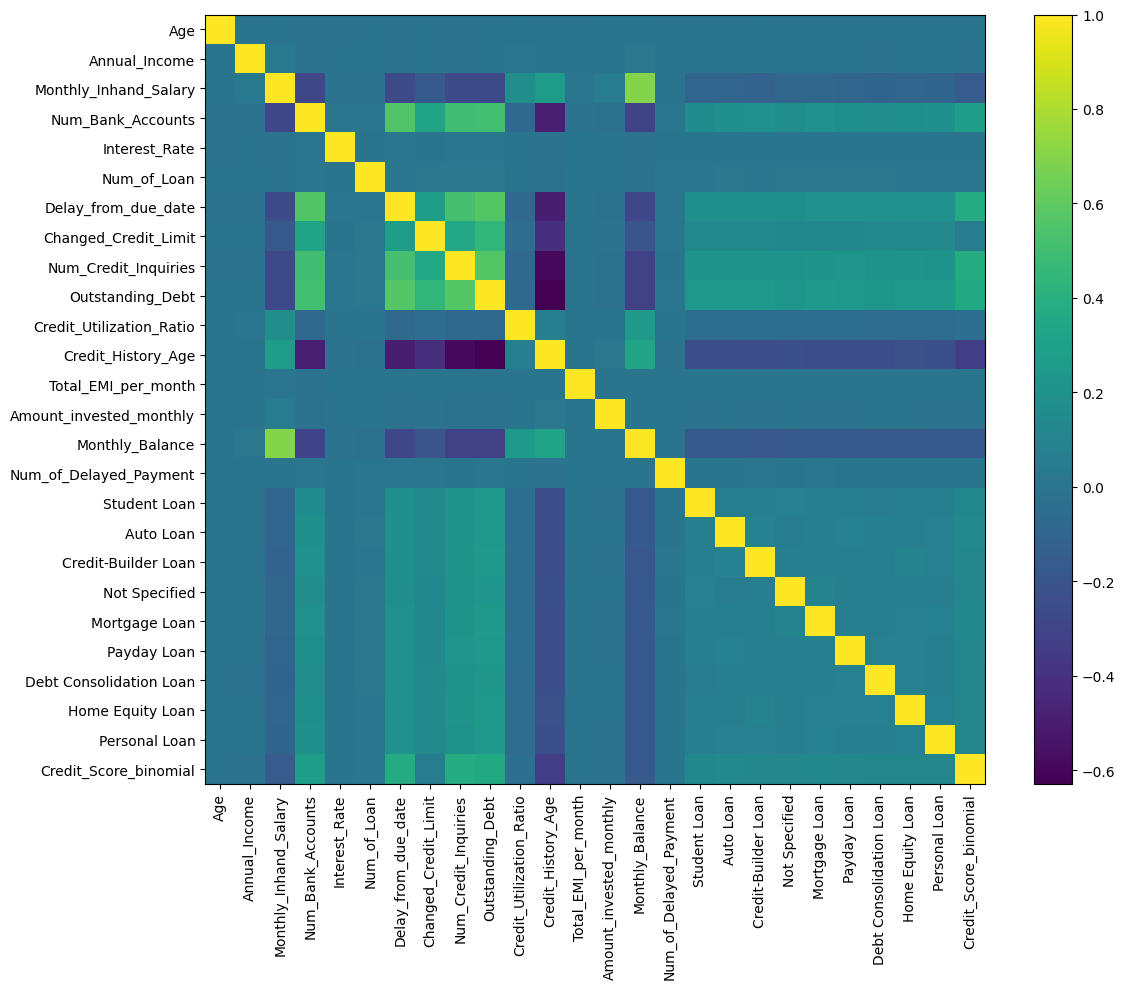

In [8]:
numeric_corr = df[numeric_features].corr(method="pearson")


plt.figure(figsize=(12, 10))
plt.imshow(numeric_corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(numeric_corr.columns)), numeric_corr.columns, rotation=90)
plt.yticks(
    range(len(numeric_corr.columns)),
    numeric_corr.columns,
)

plt.tight_layout()

plt.show()

In [9]:
correlation_analysis("Credit_Score_binomial", df[numeric_features])

,feature,correlation,method
9,Outstanding_Debt,0.414349,spearman
4,Interest_Rate,0.378270,spearman
8,Num_Credit_Inquiries,0.373962,spearman
6,Delay_from_due_date,0.353887,spearman
11,Credit_History_Age,-0.336134,spearman
3,Num_Bank_Accounts,0.292642,spearman
5,Num_of_Loan,0.286439,spearman
15,Num_of_Delayed_Payment,0.253456,spearman
14,Monthly_Balance,-0.195572,spearman
1,Annual_Income,-0.166970,spearman


# Salaries 

In [10]:
df["anual_month_salary_ratio"] = df["Annual_Income"] / df["Monthly_Inhand_Salary"]
print(
    df["anual_month_salary_ratio"].describe(percentiles=[0.9, 0.95, 0.99, 0.995, 0.999])
)

(df["anual_month_salary_ratio"] > 21).mean()

count    100000.000000
mean         67.191730
std         834.982228
min           8.089821
50%          12.025802
90%          13.555580
95%          14.570633
99%          23.184098
99.5%      3318.080014
99.9%     13133.161038
max       54110.522117
Name: anual_month_salary_ratio, dtype: float64


np.float64(0.01062)

In [11]:
df[
    [
        "Customer_ID",
        "num_month",
        "Annual_Income",
        "Monthly_Inhand_Salary",
        "anual_month_salary_ratio",
        "Credit_Score_binomial",
    ]
].sort_values(by="anual_month_salary_ratio", ascending=False)

,Customer_ID,num_month,Annual_Income,Monthly_Inhand_Salary,anual_month_salary_ratio,Credit_Score_binomial
2470,CUS_0x14e5,202207,22299600.00,412.112083,54110.522117,0
42698,CUS_0x6079,202203,23393201.00,458.671250,51002.108809,1
39983,CUS_0x5bba,202208,23713472.00,512.003333,46315.073470,1
41183,CUS_0x5dfa,202208,23834698.00,684.157917,34838.006576,0
63674,CUS_0x8763,202203,19885293.00,589.001250,33761.037010,1
...,...,...,...,...,...,...
67359,CUS_0x8df6,202208,7174.99,886.915833,8.089821,0
67354,CUS_0x8df6,202203,7174.99,886.915833,8.089821,0
67353,CUS_0x8df6,202202,7174.99,886.915833,8.089821,0
67352,CUS_0x8df6,202201,7174.99,886.915833,8.089821,0


In [12]:
df[["Annual_Income", "Monthly_Inhand_Salary"]].corr(method="spearman")

,Annual_Income,Monthly_Inhand_Salary
Annual_Income,1.000000,0.974706
Monthly_Inhand_Salary,0.974706,1.000000


In [13]:
df[df["anual_month_salary_ratio"] < 21][
    ["Annual_Income", "Monthly_Inhand_Salary"]
].corr(method="pearson")

,Annual_Income,Monthly_Inhand_Salary
Annual_Income,1.000000,0.998202
Monthly_Inhand_Salary,0.998202,1.000000


In [14]:
features_to_drop += ["Monthly_Inhand_Salary"]
features_to_drop

['Monthly_Inhand_Salary']

# Num_Bank_Accounts

In [15]:
df["Num_Bank_Accounts"].describe()

count    100000.00000
mean          5.36871
std           2.59310
min           0.00000
25%           3.00000
50%           5.00000
75%           7.00000
max          10.00000
Name: Num_Bank_Accounts, dtype: float64

In [16]:
correlation_analysis("Num_Bank_Accounts", df[numeric_features])

,feature,correlation,method
14,Num_of_Delayed_Payment,0.575856,spearman
5,Delay_from_due_date,0.570492,spearman
3,Interest_Rate,0.568289,spearman
7,Num_Credit_Inquiries,0.502774,spearman
8,Outstanding_Debt,0.498277,spearman
10,Credit_History_Age,-0.491413,spearman
4,Num_of_Loan,0.419026,spearman
13,Monthly_Balance,-0.310947,spearman
24,Credit_Score_binomial,0.292642,spearman
6,Changed_Credit_Limit,0.284880,spearman


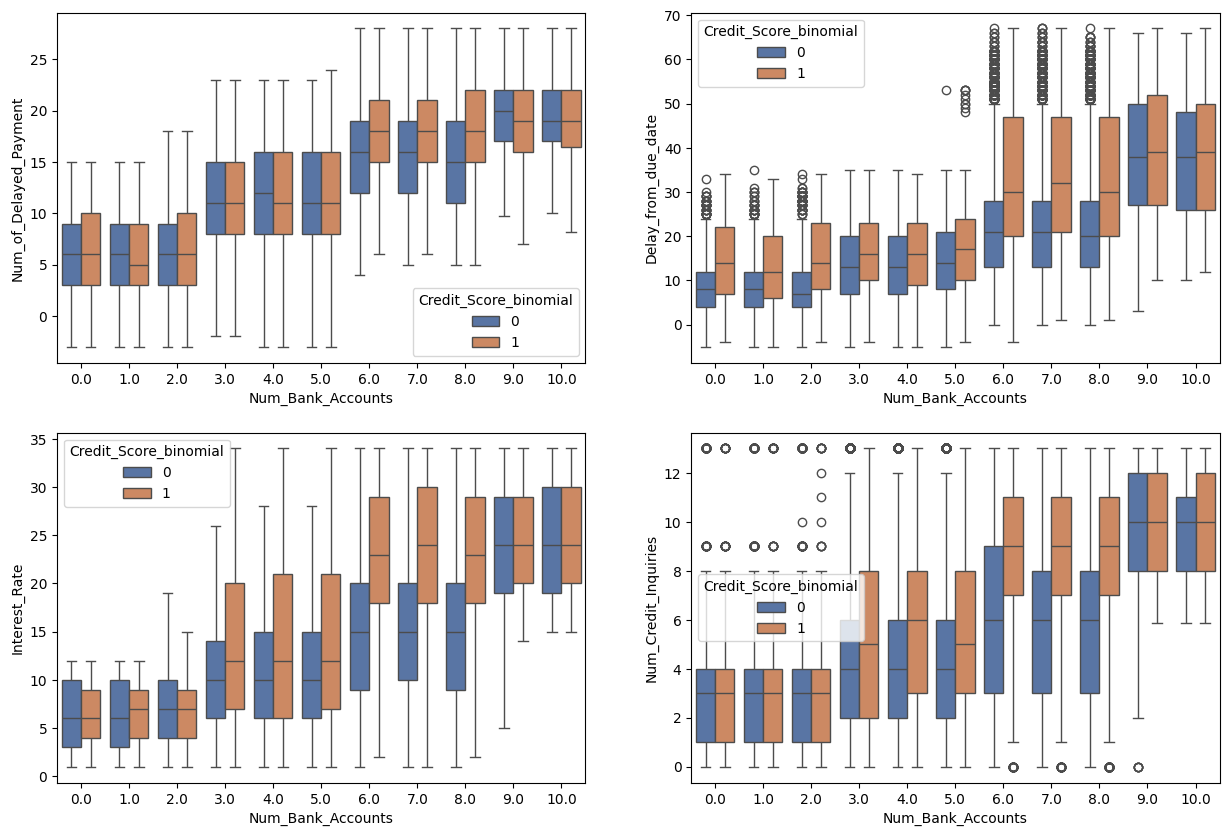

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.boxplot(
    df,
    x="Num_Bank_Accounts",
    y="Num_of_Delayed_Payment",
    showfliers=False,
    hue="Credit_Score_binomial",
    ax=axes[0, 0],
)

sns.boxplot(
    df,
    x="Num_Bank_Accounts",
    y="Delay_from_due_date",
    hue="Credit_Score_binomial",
    ax=axes[0, 1],
)

sns.boxplot(
    df,
    x="Num_Bank_Accounts",
    y="Interest_Rate",
    hue="Credit_Score_binomial",
    ax=axes[1, 0],
    showfliers=False,
)

sns.boxplot(
    df,
    x="Num_Bank_Accounts",
    y="Num_Credit_Inquiries",
    hue="Credit_Score_binomial",
    ax=axes[1, 1],
)

plt.show()

# Interest rate

count    100000.000000
mean         72.466040
std         466.422621
min           1.000000
50%          13.000000
95%          33.000000
97.5%        34.000000
98.5%      1473.030000
99%        2865.010000
max        5797.000000
Name: Interest_Rate, dtype: float64


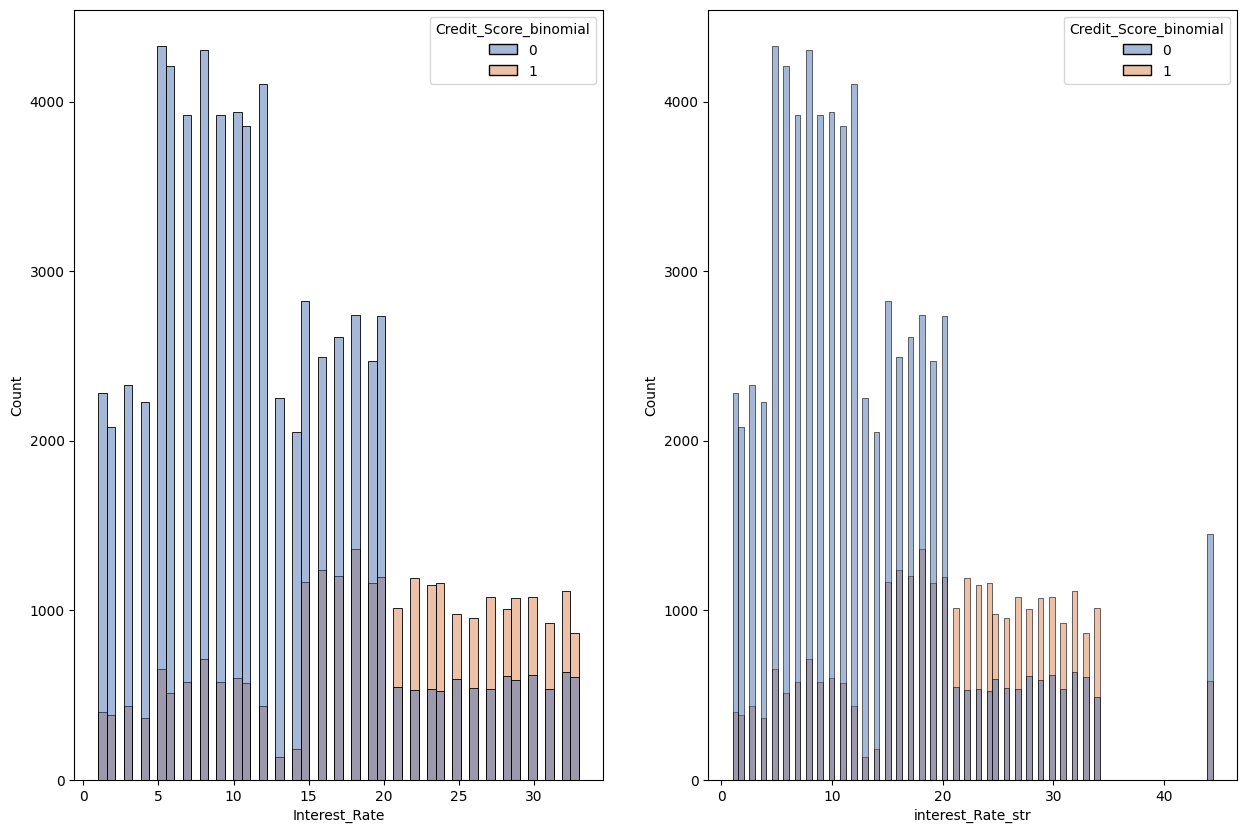

In [39]:
print(df["Interest_Rate"].describe(percentiles=(0.95, 0.975, 0.985, 0.99)))
df["interest_Rate_str"] = np.where(df["Interest_Rate"] > 35, 44.44, df["Interest_Rate"])

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
sns.histplot(
    df[df["Interest_Rate"] <= df["Interest_Rate"].quantile(0.95)],
    x="Interest_Rate",
    hue="Credit_Score_binomial",
    ax=axes[0],
)

sns.histplot(df, x="interest_Rate_str", hue="Credit_Score_binomial", ax=axes[1])
plt.show()

In [40]:
correlation_analysis("Interest_Rate", df[numeric_features])

,feature,correlation,method
8,Outstanding_Debt,0.586868,spearman
7,Num_Credit_Inquiries,0.579082,spearman
3,Num_Bank_Accounts,0.568289,spearman
10,Credit_History_Age,-0.553522,spearman
5,Delay_from_due_date,0.549342,spearman
14,Num_of_Delayed_Payment,0.543913,spearman
4,Num_of_Loan,0.466841,spearman
24,Credit_Score_binomial,0.378270,spearman
13,Monthly_Balance,-0.332609,spearman
6,Changed_Credit_Limit,0.315184,spearman
